In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [5]:
# Load Dataset
# ==========================================

df = pd.read_csv("netflix_titles_cleaned.csv")

print(df.head())
print(df.info())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [6]:
# Data Preparation
# ==========================================

# Convert duration to numeric
df["duration_num"] = df["duration"].astype(str).str.extract(r'(\d+)')
df["duration_num"] = pd.to_numeric(df["duration_num"], errors="coerce")
df["duration_num"] = df["duration_num"].fillna(df["duration_num"].median())

# Select important columns
features = [
    "release_year",
    "duration_num",
    "rating",
    "country",
    "listed_in"
]

data = df[features].copy()

# Fill missing values
data["country"] = data["country"].fillna("Unknown")
data["rating"] = data["rating"].fillna("Unknown")
data["listed_in"] = data["listed_in"].fillna("Unknown")

# One-Hot Encoding
data = pd.get_dummies(data)

# Fill numeric missing values
for col in data.columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("Data Prepared Successfully!")

Data Prepared Successfully!


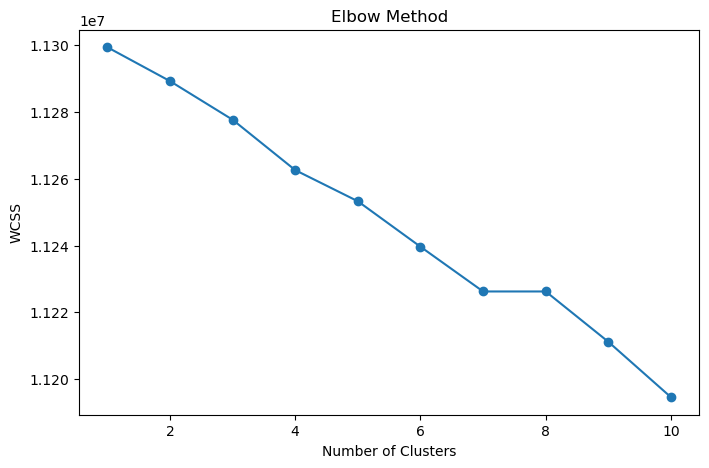

In [7]:
# K-Means Clustering - Elbow Method
# ==========================================

wcss = []

for i in range(1, 11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_data)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.savefig("elbow_method.png")
plt.show()

In [8]:
# Apply K-Means Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

print(df[["title", "Cluster"]].head())

                   title  Cluster
0   Dick Johnson Is Dead        1
1          Blood & Water        3
2              Ganglands        3
3  Jailbirds New Orleans        3
4           Kota Factory        3


In [9]:
# Cluster Summary
# ==========================================

print("\n===== Cluster Summary =====")

for cluster in sorted(df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    cluster_data = df[df["Cluster"] == cluster]

    print("\nContent Type:")
    print(cluster_data["type"].value_counts())

    print("\nTop Countries:")
    print(cluster_data["country"].value_counts().head())

    print("\nTop Genres:")
    print(cluster_data["listed_in"].value_counts().head())

    print("-"*50)


===== Cluster Summary =====

Cluster 0

Content Type:
type
TV Show    14
Movie       1
Name: count, dtype: int64

Top Countries:
country
Russia    15
Name: count, dtype: int64

Top Genres:
listed_in
kids' tv                                             4
crime tv shows, international tv shows, tv dramas    4
international tv shows, tv dramas                    2
kids' tv, korean tv shows, tv comedies               1
international tv shows, tv dramas, tv mysteries      1
Name: count, dtype: int64
--------------------------------------------------

Cluster 1

Content Type:
type
Movie    1409
Name: count, dtype: int64

Top Countries:
country
United States                    856
United Kingdom, United States     45
United Kingdom                    39
United States, United Kingdom     27
United States, Canada             21
Name: count, dtype: int64

Top Genres:
listed_in
action & adventure                      123
dramas                                   98
comedies                       

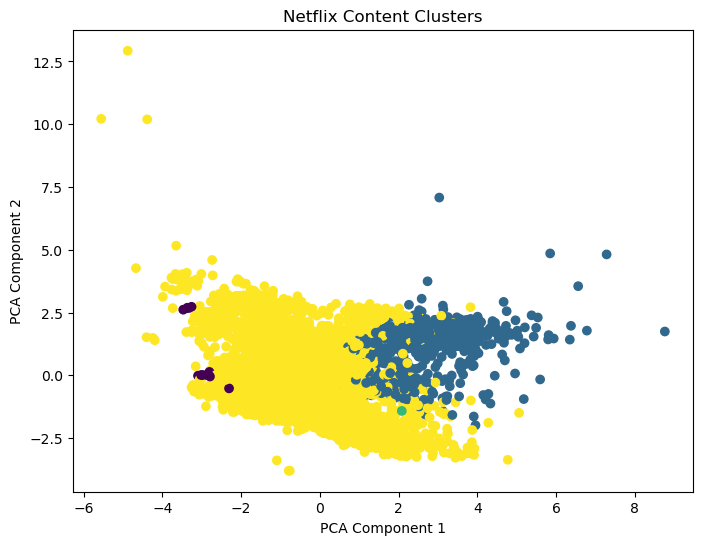

In [10]:
# PCA Visualization
# ==========================================

pca = PCA(n_components=2)

components = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Netflix Content Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.savefig("clusters_pca.png")
plt.show()

In [12]:
# Classification
# Predict Movie vs TV Show
# ==========================================

target = df["type"]

X = data
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [16]:
# Train Random Forest
# ==========================================

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)


In [17]:
# Model Evaluation
# ==========================================

print("Accuracy")
print(accuracy_score(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

print("\nConfusion Matrix")
cm = confusion_matrix(y_test, pred)

print(cm)

Accuracy
1.0

Classification Report
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1214
     TV Show       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762


Confusion Matrix
[[1214    0]
 [   0  548]]


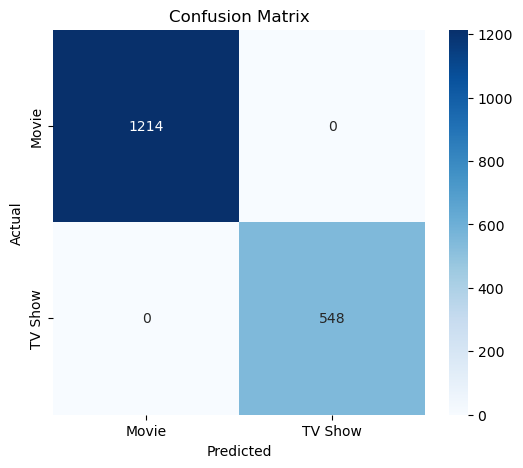

In [18]:
# Confusion Matrix Visualization
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()


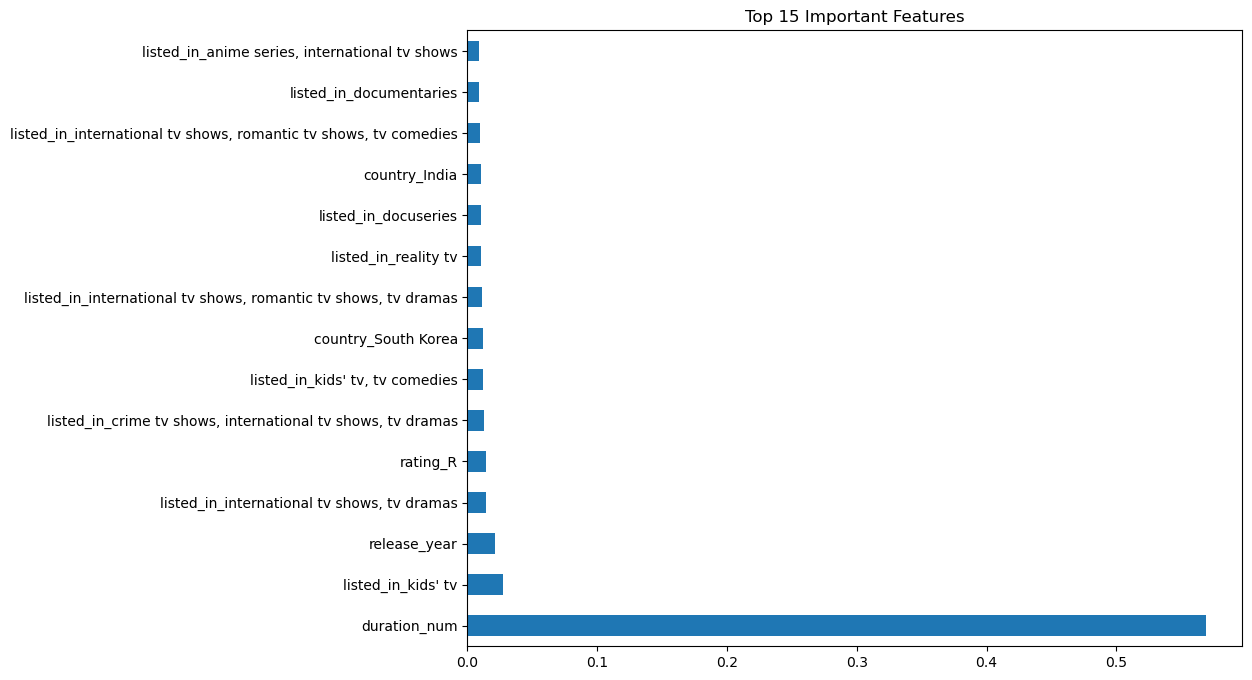


Top Important Features
duration_num                                                        0.568682
listed_in_kids' tv                                                  0.027512
release_year                                                        0.021269
listed_in_international tv shows, tv dramas                         0.014605
rating_R                                                            0.014530
listed_in_crime tv shows, international tv shows, tv dramas         0.012571
listed_in_kids' tv, tv comedies                                     0.012276
country_South Korea                                                 0.011996
listed_in_international tv shows, romantic tv shows, tv dramas      0.011498
listed_in_reality tv                                                0.010357
listed_in_docuseries                                                0.010322
country_India                                                       0.010241
listed_in_international tv shows, romantic tv shows,

In [19]:
# Feature Importance
# ==========================================

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.savefig("feature_importance.png")

plt.show()

print("\nTop Important Features")

print(importance.head(15))



In [20]:
# Save Final Dataset
# ==========================================

df.to_csv(
    "netflix_milestone3_output.csv",
    index=False
)

print("Milestone 3 Completed Successfully!")



Milestone 3 Completed Successfully!
